Librerías importadas.

--- Información del archivo PIB (pimera vista) ---
       Country    2020      2021      2022      2023      2024      2025
0  Afghanistan   20136   14278.0   14501.0   17248.0       NaN       NaN
1      Albania   15271   18086.0   19185.0   23388.0   27259.0   28372.0
2      Algeria  164774  185850.0  225709.0  247789.0  264913.0  268885.0
3      Andorra    2885    3325.0    3376.0    3786.0    4038.0    4035.0
4       Angola   66521   84375.0  142442.0  109764.0  115946.0  113343.0

--- Información del archivo Esperanza de Vida (primera vista) ---
   IndicatorCode                         Indicator ParentLocationCode  \
0  WHOSIS_000001  Life expectancy at birth (years)                AFR   
1  WHOSIS_000001  Life expectancy at birth (years)                AFR   
2  WHOSIS_000001  Life expectancy at birth (years)                AFR   
3  WHOSIS_000001  Life expectancy at birth (years)                AFR   
4  WHOSIS_000001  Life expectancy at birth (years)      

C:\Users\thoma\AppData\Local\Temp\ipykernel_21096\103742743.py:79: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  merged_df_clean['Log_GDP_2021'] = np.log10(merged_df_clean['GDP_2021'])


Datos finales con Log(PIB) aplicado:
               Country  GDP_2021  LifeExpectancy_2021  Log_GDP_2021
0          Afghanistan   14278.0                 59.1      4.154667
1              Albania   18086.0                 76.4      4.257343
2              Algeria  185850.0                 76.0      5.269163
3               Angola   84375.0                 62.1      4.926214
4  Antigua and Barbuda    1602.0                 76.9      3.204663

Gráfico de dispersión 'gdp_vs_life_expectancy_scatterplot.png' guardado.


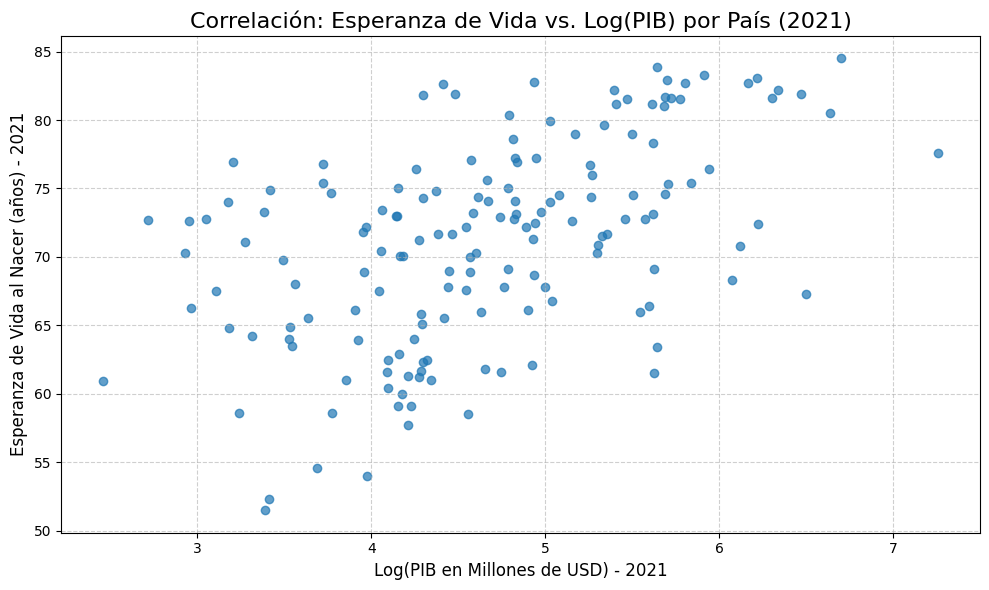

Gráficos de histogramas 'data_distributions_histograms.png' guardados.


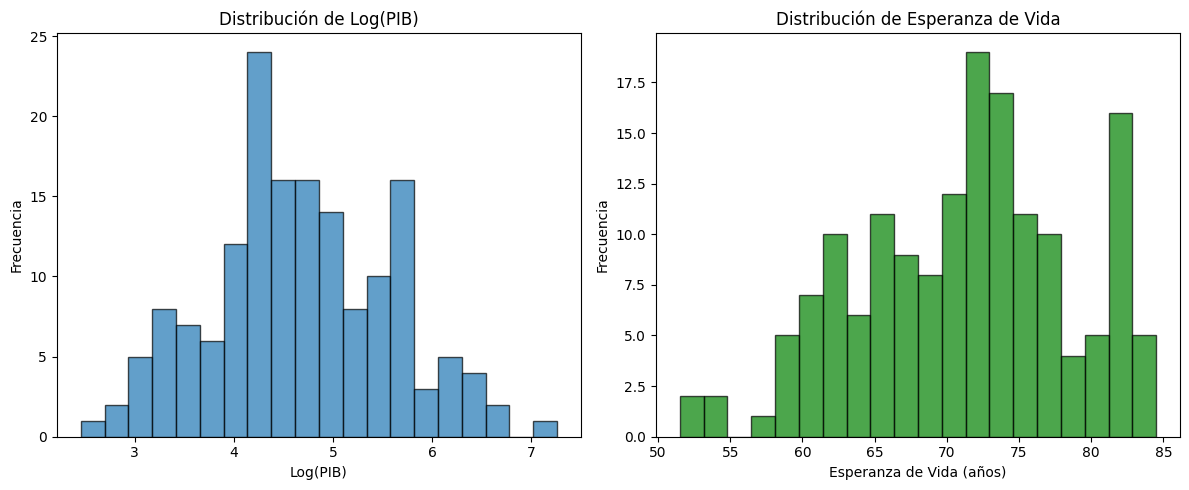



--- Matriz de Correlación de Pearson ---
                     Log_GDP_2021  LifeExpectancy_2021
Log_GDP_2021             1.000000             0.512633
LifeExpectancy_2021      0.512633             1.000000


El coeficiente de correlación entre Log(PIB) y Esperanza de Vida es: 0.5126

Datos finales listos para la regresión guardados en: datos_combinados_pib_esperanza_vida.csv


In [4]:
# --- Importar Librerías ---
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import os

print("Librerías importadas.")

# --- Paso 1: Cargar y Explorar Datos ---
path1 = os.path.join('data_2025', 'pib2020-2025.csv')
path2 = os.path.join('data_2025', 'WHO_life_expectancy.csv')


try:
    pib_df = pd.read_csv(path1)
    life_exp_df = pd.read_csv(path2)

    print("\n--- Información del archivo PIB (pimera vista) ---")
    print(pib_df.head())
    
    print("\n--- Información del archivo Esperanza de Vida (primera vista) ---")
    print(life_exp_df.head())

    # --- Paso 2: Limpiar Datos de Esperanza de Vida (WHO) ---
    print("\n--- Limpiando datos de Esperanza de Vida (WHO)... ---")
    
    # Filtrar por las condiciones deseadas
    life_exp_filtered = life_exp_df[
        (life_exp_df['Indicator'] == 'Life expectancy at birth (years)') &
        (life_exp_df['Dim1'] == 'Both sexes') &
        (life_exp_df['Period'] == 2021)
    ].copy()

    # Extraer el valor numérico de la columna 'Value'
    # Coge la primera parte del string antes del espacio (ej. "48.7" de "48.7 [47.8-49.7]")
    life_exp_filtered['Value_Clean'] = life_exp_filtered['Value'].str.split(' ', expand=True)[0]
    life_exp_filtered['Value_Clean'] = pd.to_numeric(life_exp_filtered['Value_Clean'], errors='coerce')

    # Seleccionar y renombrar las columnas para la unión
    life_exp_clean = life_exp_filtered[['Location', 'Value_Clean']].copy()
    life_exp_clean.rename(columns={'Location': 'Country', 'Value_Clean': 'LifeExpectancy_2021'}, inplace=True)
    
    print("Datos de Esperanza de Vida (WHO) limpios:")
    print(life_exp_clean.head())

    # --- Paso 3: Limpiar Datos del PIB ---
    print("\n--- Limpiando datos del PIB... ---")
    
    # Seleccionar y renombrar columnas
    pib_clean = pib_df[['Country', '2021']].copy()
    pib_clean.rename(columns={'2021': 'GDP_2021'}, inplace=True)

    # Asegurarse de que el GDP es numérico
    pib_clean['GDP_2021'] = pd.to_numeric(pib_clean['GDP_2021'], errors='coerce')

    print("Datos del PIB (limpios):")
    print(pib_clean.head())

    # --- Paso 4: Unir (Merge) los Datos ---
    print("\n--- Uniendo los dos conjuntos de datos... ---")

    # Unir los dos DataFrames limpios en la columna 'Country'
    merged_df = pd.merge(pib_clean, life_exp_clean, on='Country', how='inner')
    
    print("Datos combinados (primeras filas):")
    print(merged_df.head())
    print(f"Total de países en datos combinados (antes de limpiar nulos): {len(merged_df)}")
    print("Valores nulos en datos combinados:")
    print(merged_df.isnull().sum())

    # --- Paso 5: Análisis de Correlación y Visualización ---
    print("\n--- Realizando análisis final y visualización... ---")

    # 1. Limpieza Final: Eliminar filas con valores nulos
    merged_df_clean = merged_df.dropna()
    print(f"Total de países en el análisis final (después de limpiar nulos): {len(merged_df_clean)}")

    # 2. Transformación: Aplicar Logaritmo al PIB
    merged_df_clean['Log_GDP_2021'] = np.log10(merged_df_clean['GDP_2021'])
    print("Datos finales con Log(PIB) aplicado:")
    print(merged_df_clean.head())

    # 3. Visualización: Gráfico de Dispersión
    plt.figure(figsize=(10, 6))
    plt.scatter(merged_df_clean['Log_GDP_2021'], merged_df_clean['LifeExpectancy_2021'], alpha=0.7)
    plt.title('Correlación: Esperanza de Vida vs. Log(PIB) por País (2021)', fontsize=16)
    plt.xlabel('Log(PIB en Millones de USD) - 2021', fontsize=12)
    plt.ylabel('Esperanza de Vida al Nacer (años) - 2021', fontsize=12)
    plt.grid(True, linestyle='--', alpha=0.6)
    plt.tight_layout()
    # Guardar y mostrar la imagen
    plt.savefig("gdp_vs_life_expectancy_scatterplot.png")
    print("\nGráfico de dispersión 'gdp_vs_life_expectancy_scatterplot.png' guardado.")
    plt.show()

    # 3b. Visualización: Histogramas
    plt.figure(figsize=(12, 5))
    
    # Histograma de Log(PIB)
    plt.subplot(1, 2, 1)
    plt.hist(merged_df_clean['Log_GDP_2021'], bins=20, edgecolor='k', alpha=0.7)
    plt.title('Distribución de Log(PIB)')
    plt.xlabel('Log(PIB)')
    plt.ylabel('Frecuencia')
    
    # Histograma de Esperanza de Vida
    plt.subplot(1, 2, 2)
    plt.hist(merged_df_clean['LifeExpectancy_2021'], bins=20, edgecolor='k', alpha=0.7, color='green')
    plt.title('Distribución de Esperanza de Vida')
    plt.xlabel('Esperanza de Vida (años)')
    plt.ylabel('Frecuencia')

    plt.tight_layout()
    plt.savefig("data_distributions_histograms.png")
    print("Gráficos de histogramas 'data_distributions_histograms.png' guardados.")
    plt.show()

    # 4. Cálculo de Correlación
    correlation_matrix = merged_df_clean[['Log_GDP_2021', 'LifeExpectancy_2021']].corr()

    print("\n" + "="*50 + "\n")
    print("--- Matriz de Correlación de Pearson ---")
    print(correlation_matrix)
    print("\n" + "="*50 + "\n")

    correlation_coefficient = correlation_matrix.loc['Log_GDP_2021', 'LifeExpectancy_2021']
    print(f"El coeficiente de correlación entre Log(PIB) y Esperanza de Vida es: {correlation_coefficient:.4f}")
    
    # 5. Guardar los datos finales
    final_data_filename = "datos_combinados_pib_esperanza_vida.csv"
    merged_df_clean.to_csv(final_data_filename, index=False)
    print(f"\nDatos finales listos para la regresión guardados en: {final_data_filename}")


except FileNotFoundError:
    print("\n--- ERROR ---")
    print("Asegúrate de que 'pib2020-2025.csv' y 'WHO_life_expectancy.csv' estén en la misma carpeta que este notebook.")
except Exception as e:
    print(f"\nOcurrió un error inesperado: {e}")

Librerías importadas.

--- Información del archivo PIB (pimera vista) ---
       Country    2020      2021      2022      2023      2024      2025
0  Afghanistan   20136   14278.0   14501.0   17248.0       NaN       NaN
1      Albania   15271   18086.0   19185.0   23388.0   27259.0   28372.0
2      Algeria  164774  185850.0  225709.0  247789.0  264913.0  268885.0
3      Andorra    2885    3325.0    3376.0    3786.0    4038.0    4035.0
4       Angola   66521   84375.0  142442.0  109764.0  115946.0  113343.0

--- Información del archivo Esperanza de Vida (primera vista) ---
   IndicatorCode                         Indicator ParentLocationCode  \
0  WHOSIS_000001  Life expectancy at birth (years)                AFR   
1  WHOSIS_000001  Life expectancy at birth (years)                AFR   
2  WHOSIS_000001  Life expectancy at birth (years)                AFR   
3  WHOSIS_000001  Life expectancy at birth (years)                AFR   
4  WHOSIS_000001  Life expectancy at birth (years)      

C:\Users\thoma\AppData\Local\Temp\ipykernel_21096\103742743.py:79: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  merged_df_clean['Log_GDP_2021'] = np.log10(merged_df_clean['GDP_2021'])


Datos finales con Log(PIB) aplicado:
               Country  GDP_2021  LifeExpectancy_2021  Log_GDP_2021
0          Afghanistan   14278.0                 59.1      4.154667
1              Albania   18086.0                 76.4      4.257343
2              Algeria  185850.0                 76.0      5.269163
3               Angola   84375.0                 62.1      4.926214
4  Antigua and Barbuda    1602.0                 76.9      3.204663

Gráfico de dispersión 'gdp_vs_life_expectancy_scatterplot.png' guardado.


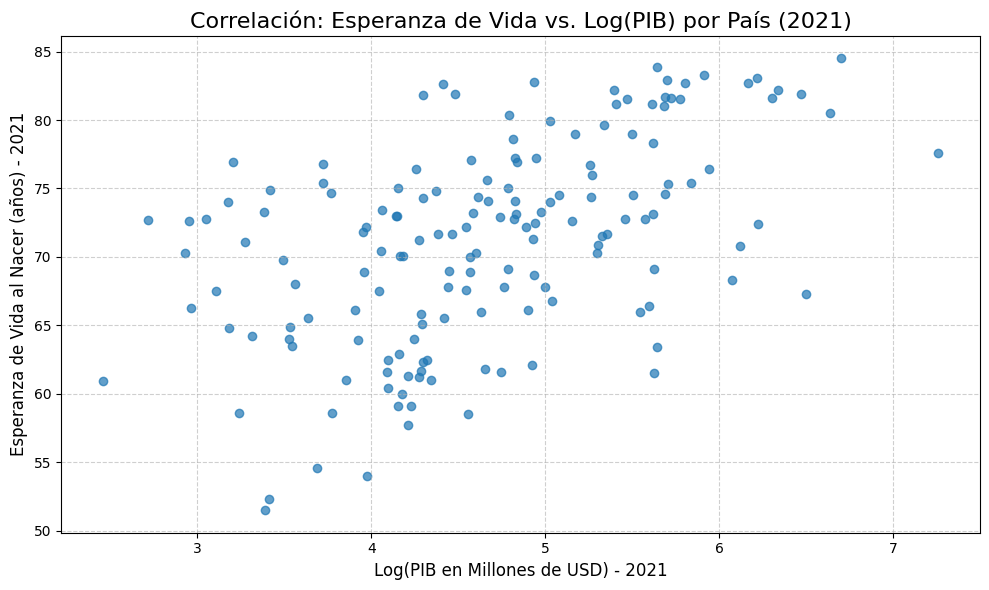

Gráficos de histogramas 'data_distributions_histograms.png' guardados.


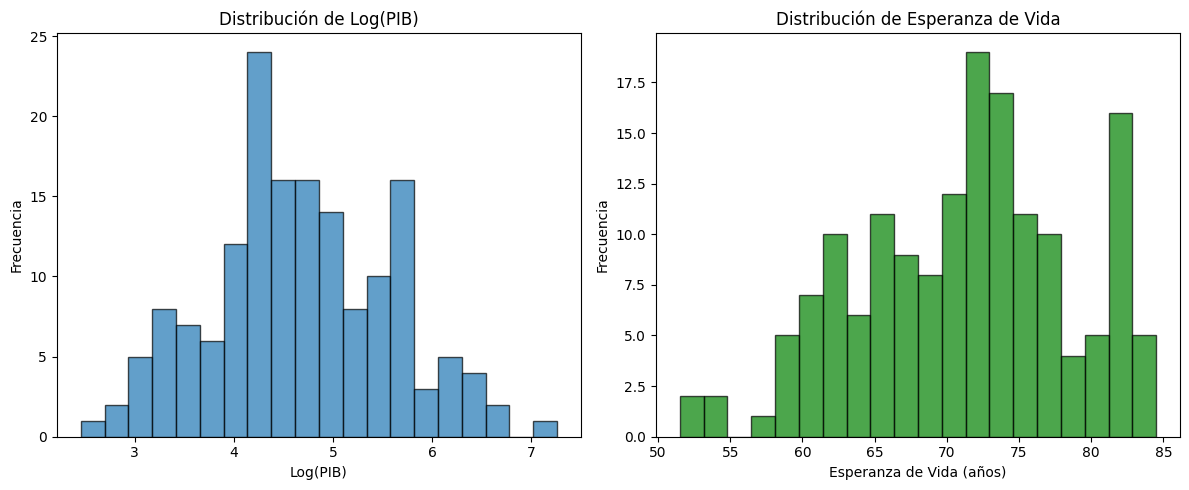



--- Matriz de Correlación de Pearson ---
                     Log_GDP_2021  LifeExpectancy_2021
Log_GDP_2021             1.000000             0.512633
LifeExpectancy_2021      0.512633             1.000000


El coeficiente de correlación entre Log(PIB) y Esperanza de Vida es: 0.5126

Datos finales listos para la regresión guardados en: datos_combinados_pib_esperanza_vida.csv


In [4]:
# --- Importar Librerías ---
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import os

print("Librerías importadas.")

# --- Paso 1: Cargar y Explorar Datos ---
path1 = os.path.join('data_2025', 'pib2020-2025.csv')
path2 = os.path.join('data_2025', 'WHO_life_expectancy.csv')


try:
    pib_df = pd.read_csv(path1)
    life_exp_df = pd.read_csv(path2)

    print("\n--- Información del archivo PIB (pimera vista) ---")
    print(pib_df.head())
    
    print("\n--- Información del archivo Esperanza de Vida (primera vista) ---")
    print(life_exp_df.head())

    # --- Paso 2: Limpiar Datos de Esperanza de Vida (WHO) ---
    print("\n--- Limpiando datos de Esperanza de Vida (WHO)... ---")
    
    # Filtrar por las condiciones deseadas
    life_exp_filtered = life_exp_df[
        (life_exp_df['Indicator'] == 'Life expectancy at birth (years)') &
        (life_exp_df['Dim1'] == 'Both sexes') &
        (life_exp_df['Period'] == 2021)
    ].copy()

    # Extraer el valor numérico de la columna 'Value'
    # Coge la primera parte del string antes del espacio (ej. "48.7" de "48.7 [47.8-49.7]")
    life_exp_filtered['Value_Clean'] = life_exp_filtered['Value'].str.split(' ', expand=True)[0]
    life_exp_filtered['Value_Clean'] = pd.to_numeric(life_exp_filtered['Value_Clean'], errors='coerce')

    # Seleccionar y renombrar las columnas para la unión
    life_exp_clean = life_exp_filtered[['Location', 'Value_Clean']].copy()
    life_exp_clean.rename(columns={'Location': 'Country', 'Value_Clean': 'LifeExpectancy_2021'}, inplace=True)
    
    print("Datos de Esperanza de Vida (WHO) limpios:")
    print(life_exp_clean.head())

    # --- Paso 3: Limpiar Datos del PIB ---
    print("\n--- Limpiando datos del PIB... ---")
    
    # Seleccionar y renombrar columnas
    pib_clean = pib_df[['Country', '2021']].copy()
    pib_clean.rename(columns={'2021': 'GDP_2021'}, inplace=True)

    # Asegurarse de que el GDP es numérico
    pib_clean['GDP_2021'] = pd.to_numeric(pib_clean['GDP_2021'], errors='coerce')

    print("Datos del PIB (limpios):")
    print(pib_clean.head())

    # --- Paso 4: Unir (Merge) los Datos ---
    print("\n--- Uniendo los dos conjuntos de datos... ---")

    # Unir los dos DataFrames limpios en la columna 'Country'
    merged_df = pd.merge(pib_clean, life_exp_clean, on='Country', how='inner')
    
    print("Datos combinados (primeras filas):")
    print(merged_df.head())
    print(f"Total de países en datos combinados (antes de limpiar nulos): {len(merged_df)}")
    print("Valores nulos en datos combinados:")
    print(merged_df.isnull().sum())

    # --- Paso 5: Análisis de Correlación y Visualización ---
    print("\n--- Realizando análisis final y visualización... ---")

    # 1. Limpieza Final: Eliminar filas con valores nulos
    merged_df_clean = merged_df.dropna()
    print(f"Total de países en el análisis final (después de limpiar nulos): {len(merged_df_clean)}")

    # 2. Transformación: Aplicar Logaritmo al PIB
    merged_df_clean['Log_GDP_2021'] = np.log10(merged_df_clean['GDP_2021'])
    print("Datos finales con Log(PIB) aplicado:")
    print(merged_df_clean.head())

    # 3. Visualización: Gráfico de Dispersión
    plt.figure(figsize=(10, 6))
    plt.scatter(merged_df_clean['Log_GDP_2021'], merged_df_clean['LifeExpectancy_2021'], alpha=0.7)
    plt.title('Correlación: Esperanza de Vida vs. Log(PIB) por País (2021)', fontsize=16)
    plt.xlabel('Log(PIB en Millones de USD) - 2021', fontsize=12)
    plt.ylabel('Esperanza de Vida al Nacer (años) - 2021', fontsize=12)
    plt.grid(True, linestyle='--', alpha=0.6)
    plt.tight_layout()
    # Guardar y mostrar la imagen
    plt.savefig("gdp_vs_life_expectancy_scatterplot.png")
    print("\nGráfico de dispersión 'gdp_vs_life_expectancy_scatterplot.png' guardado.")
    plt.show()

    # 3b. Visualización: Histogramas
    plt.figure(figsize=(12, 5))
    
    # Histograma de Log(PIB)
    plt.subplot(1, 2, 1)
    plt.hist(merged_df_clean['Log_GDP_2021'], bins=20, edgecolor='k', alpha=0.7)
    plt.title('Distribución de Log(PIB)')
    plt.xlabel('Log(PIB)')
    plt.ylabel('Frecuencia')
    
    # Histograma de Esperanza de Vida
    plt.subplot(1, 2, 2)
    plt.hist(merged_df_clean['LifeExpectancy_2021'], bins=20, edgecolor='k', alpha=0.7, color='green')
    plt.title('Distribución de Esperanza de Vida')
    plt.xlabel('Esperanza de Vida (años)')
    plt.ylabel('Frecuencia')

    plt.tight_layout()
    plt.savefig("data_distributions_histograms.png")
    print("Gráficos de histogramas 'data_distributions_histograms.png' guardados.")
    plt.show()

    # 4. Cálculo de Correlación
    correlation_matrix = merged_df_clean[['Log_GDP_2021', 'LifeExpectancy_2021']].corr()

    print("\n" + "="*50 + "\n")
    print("--- Matriz de Correlación de Pearson ---")
    print(correlation_matrix)
    print("\n" + "="*50 + "\n")

    correlation_coefficient = correlation_matrix.loc['Log_GDP_2021', 'LifeExpectancy_2021']
    print(f"El coeficiente de correlación entre Log(PIB) y Esperanza de Vida es: {correlation_coefficient:.4f}")
    
    # 5. Guardar los datos finales
    final_data_filename = "datos_combinados_pib_esperanza_vida.csv"
    merged_df_clean.to_csv(final_data_filename, index=False)
    print(f"\nDatos finales listos para la regresión guardados en: {final_data_filename}")


except FileNotFoundError:
    print("\n--- ERROR ---")
    print("Asegúrate de que 'pib2020-2025.csv' y 'WHO_life_expectancy.csv' estén en la misma carpeta que este notebook.")
except Exception as e:
    print(f"\nOcurrió un error inesperado: {e}")

In [6]:

path1 = os.path.join('data_2025', 'pib2020-2025.csv')
path2 = os.path.join('data_2025', 'WHO_life_expectancy.csv')
# Cargar los datasets
gdp = pd.read_csv(path1)           # tiene columna 'Country'
life = pd.read_csv(path2)   # tiene columna 'Location'

# Unir según país
# inner: solo países que aparezcan en ambos
# si quieres conservar todos los del PIB, usa how="left"
merged = pd.merge(
    gdp,
    life,
    left_on="Country",
    right_on="Location",
    how="inner"
)

display(merged)


,Country,2020,2021,2022,2023,2024,2025,IndicatorCode,Indicator,ParentLocationCode,ParentLocation,Location type,SpatialDimValueCode,Location,Period type,Period,Dim1 type,Dim1,Value
0,Afghanistan,20136,14278.0,14501.0,17248.0,NaN,NaN,WHOSIS_000001,Life expectancy at birth (years),EMR,Eastern Mediterranean,Country,AFG,Afghanistan,Year,2021,Sex,Male,57.4 [56.6-58.2]
1,Afghanistan,20136,14278.0,14501.0,17248.0,NaN,NaN,WHOSIS_000001,Life expectancy at birth (years),EMR,Eastern Mediterranean,Country,AFG,Afghanistan,Year,2021,Sex,Both sexes,59.1 [58.3-59.9]
2,Afghanistan,20136,14278.0,14501.0,17248.0,NaN,NaN,WHOSIS_000001,Life expectancy at birth (years),EMR,Eastern Mediterranean,Country,AFG,Afghanistan,Year,2021,Sex,Female,61.0 [60.2-61.7]
3,Afghanistan,20136,14278.0,14501.0,17248.0,NaN,NaN,WHOSIS_000015,Life expectancy at age 60 (years),EMR,Eastern Mediterranean,Country,AFG,Afghanistan,Year,2021,Sex,Male,13.6 [13.1-14.1]
4,Afghanistan,20136,14278.0,14501.0,17248.0,NaN,NaN,WHOSIS_000015,Life expectancy at age 60 (years),EMR,Eastern Mediterranean,Country,AFG,Afghanistan,Year,2021,Sex,Both sexes,13.7 [13.2-14.2]
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
21247,Zimbabwe,26878,36016.0,32613.0,35144.0,35224.0,38172.0,WHOSIS_000001,Life expectancy at birth (years),AFR,Africa,Country,ZWE,Zimbabwe,Year,2000,Sex,Both sexes,45.7 [44.1-47.6]
21248,Zimbabwe,26878,36016.0,32613.0,35144.0,35224.0,38172.0,WHOSIS_000001,Life expectancy at birth (years),AFR,Africa,Country,ZWE,Zimbabwe,Year,2000,Sex,Female,46.7 [44.7-48.4]
21249,Zimbabwe,26878,36016.0,32613.0,35144.0,35224.0,38172.0,WHOSIS_000015,Life expectancy at age 60 (years),AFR,Africa,Country,ZWE,Zimbabwe,Year,2000,Sex,Male,11.9 [11.4-12.6]
21250,Zimbabwe,26878,36016.0,32613.0,35144.0,35224.0,38172.0,WHOSIS_000015,Life expectancy at age 60 (years),AFR,Africa,Country,ZWE,Zimbabwe,Year,2000,Sex,Both sexes,13.6 [13.0-14.2]



--- DataFrame gdp_tidy (formato largo) ---
       Country  Year       GDP
0  Afghanistan  2020   20136.0
1      Albania  2020   15271.0
2      Algeria  2020  164774.0
3      Andorra  2020    2885.0
4       Angola  2020   66521.0
Librerías importadas.

--- Información del dataframe de PIB (tidy) ---
       Country  Year       GDP
0  Afghanistan  2020   20136.0
1      Albania  2020   15271.0
2      Algeria  2020  164774.0
3      Andorra  2020    2885.0
4       Angola  2020   66521.0

--- Información del archivo Esperanza de Vida (primera vista) ---
   IndicatorCode                         Indicator ParentLocationCode  \
0  WHOSIS_000001  Life expectancy at birth (years)                AFR   
1  WHOSIS_000001  Life expectancy at birth (years)                AFR   
2  WHOSIS_000001  Life expectancy at birth (years)                AFR   
3  WHOSIS_000001  Life expectancy at birth (years)                AFR   
4  WHOSIS_000001  Life expectancy at birth (years)                EMR   

       

C:\Users\thoma\AppData\Local\Temp\ipykernel_21096\1722357659.py:103: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  merged_df_clean['Log_GDP_2021'] = np.log10(merged_df_clean['GDP_2021'])



Gráfico de dispersión 'gdp_vs_life_expectancy_scatterplot.png' guardado.


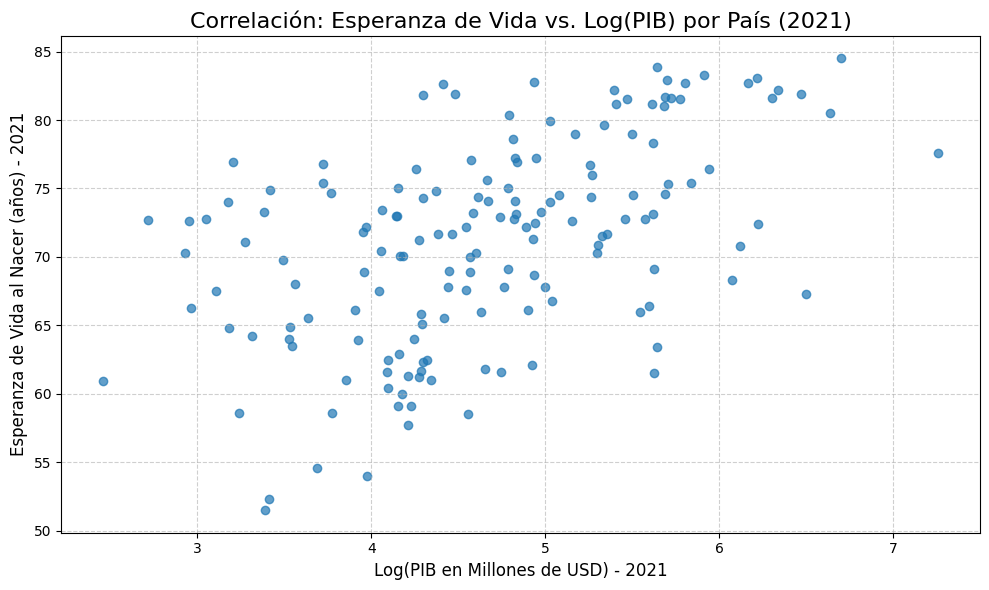

Gráficos de histogramas 'data_distributions_histograms.png' guardados.


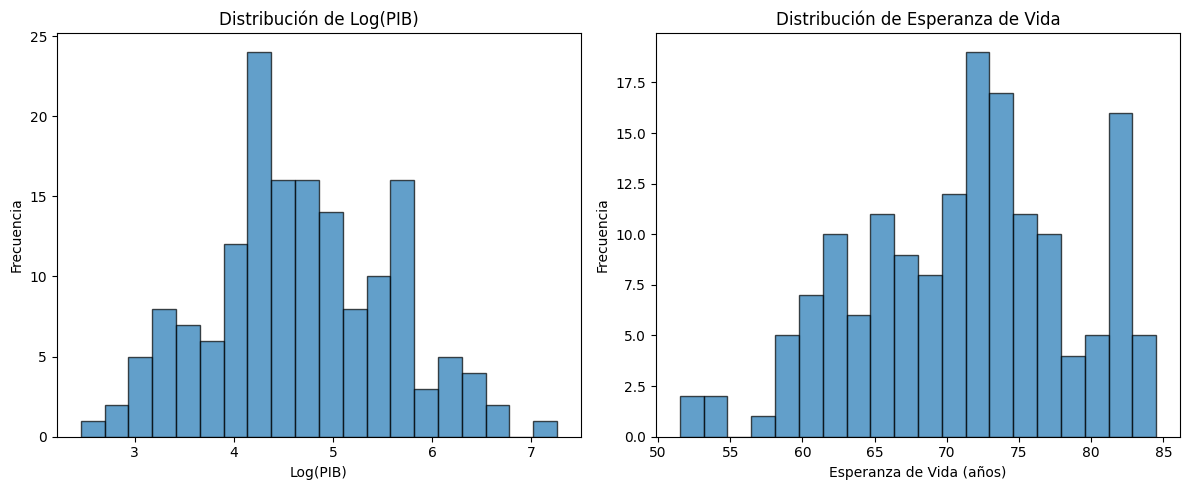



--- Matriz de Correlación de Pearson ---
                     Log_GDP_2021  LifeExpectancy_2021
Log_GDP_2021             1.000000             0.512633
LifeExpectancy_2021      0.512633             1.000000


El coeficiente de correlación entre Log(PIB) y Esperanza de Vida es: 0.5126

Datos finales listos para la regresión guardados en: datos_combinados_pib_esperanza_vida.csv


In [8]:
# --- Importar Librerías ---
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import os

# Ya tienes esto:
path1 = os.path.join('data_2025', 'pib2020-2025.csv')
pib_df = pd.read_csv(path1)

# --- Crear gdp_tidy a partir de pib_df en formato ancho ---
# Queda con columnas: Country, Year, GDP

# Tomamos todas las columnas que sean años (todas menos 'Country')
year_cols = [col for col in pib_df.columns if col != "Country"]

gdp_tidy = pib_df.melt(
    id_vars="Country",        # columna que se mantiene fija
    value_vars=year_cols,     # columnas de años
    var_name="Year",          # nuevo nombre para la columna de año
    value_name="GDP"          # nuevo nombre para la columna de PIB
)

# Aseguramos tipos correctos
gdp_tidy["Year"] = gdp_tidy["Year"].astype(int)
gdp_tidy["GDP"] = pd.to_numeric(gdp_tidy["GDP"], errors="coerce")

print("\n--- DataFrame gdp_tidy (formato largo) ---")
print(gdp_tidy.head())

print("Librerías importadas.")

# --- Paso 1: Cargar y Explorar Datos ---
# OJO: aquí solo usamos path2 para WHO; el PIB ya viene en el dataframe gdp_tidy
path2 = os.path.join('data_2025', 'WHO_life_expectancy.csv')

try:
    # DataFrame de PIB YA PROCESADO (el que te pasé antes)
    # Debe existir en tu notebook algo como:
    # gdp_tidy = ...  # columnas: Country, Year, GDP
    print("\n--- Información del dataframe de PIB (tidy) ---")
    print(gdp_tidy.head())

    # Cargamos archivo de esperanza de vida
    life_exp_df = pd.read_csv(path2)

    print("\n--- Información del archivo Esperanza de Vida (primera vista) ---")
    print(life_exp_df.head())

    # --- Paso 2: Limpiar Datos de Esperanza de Vida (WHO) ---
    print("\n--- Limpiando datos de Esperanza de Vida (WHO)... ---")
    
    life_exp_filtered = life_exp_df[
        (life_exp_df['Indicator'] == 'Life expectancy at birth (years)') &
        (life_exp_df['Dim1'] == 'Both sexes') &
        (life_exp_df['Period'] == 2021)
    ].copy()

    # Tomar la primera parte numérica del string en 'Value'
    life_exp_filtered['Value_Clean'] = life_exp_filtered['Value'].str.split(' ', expand=True)[0]
    life_exp_filtered['Value_Clean'] = pd.to_numeric(life_exp_filtered['Value_Clean'], errors='coerce')

    # Seleccionar y renombrar columnas para la unión
    life_exp_clean = life_exp_filtered[['Location', 'Value_Clean']].copy()
    life_exp_clean.rename(columns={'Location': 'Country',
                                   'Value_Clean': 'LifeExpectancy_2021'}, inplace=True)
    
    print("Datos de Esperanza de Vida (WHO) limpios:")
    print(life_exp_clean.head())

    # --- Paso 3: Tomar solo el PIB 2021 desde el dataframe tidy ---
    print("\n--- Tomando datos del PIB 2021 desde el dataframe tidy... ---")

    # Filtrar año 2021 y quedarnos con Country + GDP
    pib_clean = gdp_tidy[gdp_tidy['Year'] == 2021][['Country', 'GDP']].copy()
    pib_clean.rename(columns={'GDP': 'GDP_2021'}, inplace=True)

    # Asegurarse de que el PIB es numérico
    pib_clean['GDP_2021'] = pd.to_numeric(pib_clean['GDP_2021'], errors='coerce')

    print("Datos del PIB 2021 (limpios, desde dataframe tidy):")
    print(pib_clean.head())

    # --- Paso 4: Unir (Merge) los Datos ---
    print("\n--- Uniendo los dos conjuntos de datos... ---")

    merged_df = pd.merge(pib_clean, life_exp_clean, on='Country', how='inner')
    
    print("Datos combinados (primeras filas):")
    print(merged_df.head())
    print(f"Total de países en datos combinados (antes de limpiar nulos): {len(merged_df)}")
    print("Valores nulos en datos combinados:")
    print(merged_df.isnull().sum())

    # --- Paso 5: Análisis de Correlación y Visualización ---
    print("\n--- Realizando análisis final y visualización... ---")

    # 1. Limpieza final: eliminar filas con NaN
    merged_df_clean = merged_df.dropna()
    print(f"Total de países en el análisis final (después de limpiar nulos): {len(merged_df_clean)}")

    # 2. Transformación: Log10 del PIB
    merged_df_clean['Log_GDP_2021'] = np.log10(merged_df_clean['GDP_2021'])
    print("Datos finales con Log(PIB) aplicado:")
    print(merged_df_clean.head())

    # 3. Gráfico de dispersión
    plt.figure(figsize=(10, 6))
    plt.scatter(merged_df_clean['Log_GDP_2021'],
                merged_df_clean['LifeExpectancy_2021'],
                alpha=0.7)
    plt.title('Correlación: Esperanza de Vida vs. Log(PIB) por País (2021)', fontsize=16)
    plt.xlabel('Log(PIB en Millones de USD) - 2021', fontsize=12)
    plt.ylabel('Esperanza de Vida al Nacer (años) - 2021', fontsize=12)
    plt.grid(True, linestyle='--', alpha=0.6)
    plt.tight_layout()
    plt.savefig("gdp_vs_life_expectancy_scatterplot.png")
    print("\nGráfico de dispersión 'gdp_vs_life_expectancy_scatterplot.png' guardado.")
    plt.show()

    # 3b. Histogramas
    plt.figure(figsize=(12, 5))
    
    # Histograma de Log(PIB)
    plt.subplot(1, 2, 1)
    plt.hist(merged_df_clean['Log_GDP_2021'], bins=20, edgecolor='k', alpha=0.7)
    plt.title('Distribución de Log(PIB)')
    plt.xlabel('Log(PIB)')
    plt.ylabel('Frecuencia')
    
    # Histograma de Esperanza de Vida
    plt.subplot(1, 2, 2)
    plt.hist(merged_df_clean['LifeExpectancy_2021'], bins=20, edgecolor='k', alpha=0.7)
    plt.title('Distribución de Esperanza de Vida')
    plt.xlabel('Esperanza de Vida (años)')
    plt.ylabel('Frecuencia')

    plt.tight_layout()
    plt.savefig("data_distributions_histograms.png")
    print("Gráficos de histogramas 'data_distributions_histograms.png' guardados.")
    plt.show()

    # 4. Correlación
    correlation_matrix = merged_df_clean[['Log_GDP_2021', 'LifeExpectancy_2021']].corr()

    print("\n" + "="*50 + "\n")
    print("--- Matriz de Correlación de Pearson ---")
    print(correlation_matrix)
    print("\n" + "="*50 + "\n")

    correlation_coefficient = correlation_matrix.loc['Log_GDP_2021', 'LifeExpectancy_2021']
    print(f"El coeficiente de correlación entre Log(PIB) y Esperanza de Vida es: {correlation_coefficient:.4f}")
    
    # 5. Guardar los datos finales
    final_data_filename = "datos_combinados_pib_esperanza_vida.csv"
    merged_df_clean.to_csv(final_data_filename, index=False)
    print(f"\nDatos finales listos para la regresión guardados en: {final_data_filename}")

except FileNotFoundError:
    print("\n--- ERROR ---")
    print("Asegúrate de que 'WHO_life_expectancy.csv' esté en la carpeta 'data_2025'.")
except NameError:
    print("\n--- ERROR ---")
    print("Asegúrate de tener en memoria el dataframe gdp_tidy (Country, Year, GDP) antes de correr este bloque.")
except Exception as e:
    print(f"\nOcurrió un error inesperado: {e}")



--- Heatmap de correlaciones ---
                     GDP_2021  Log_GDP_2021  LifeExpectancy_2021
GDP_2021             1.000000      0.473655             0.217111
Log_GDP_2021         0.473655      1.000000             0.512633
LifeExpectancy_2021  0.217111      0.512633             1.000000
Heatmap 'heatmap_correlaciones.png' guardado.


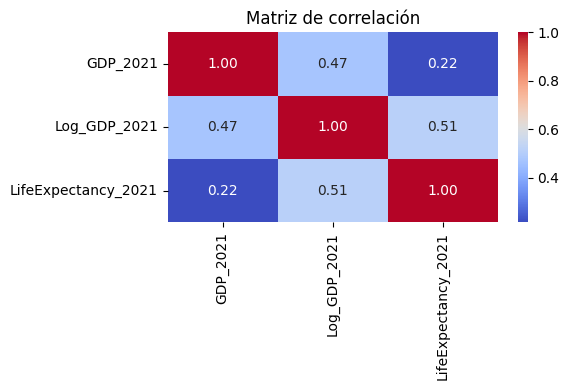


--- Correlación Pearson entre Log_GDP_2021 y LifeExpectancy_2021 ---
Correlación de Pearson: 0.5126

--- Regresión lineal simple ---
Recta ajustada: y = 4.1192 * x + 51.9302
MSE  (Error cuadrático medio): 39.7267
RMSE (Raíz del MSE): 6.3029
R²   (Coeficiente de determinación): 0.2628
Gráfico 'regresion_lineal_gdp_lifeexp.png' guardado.


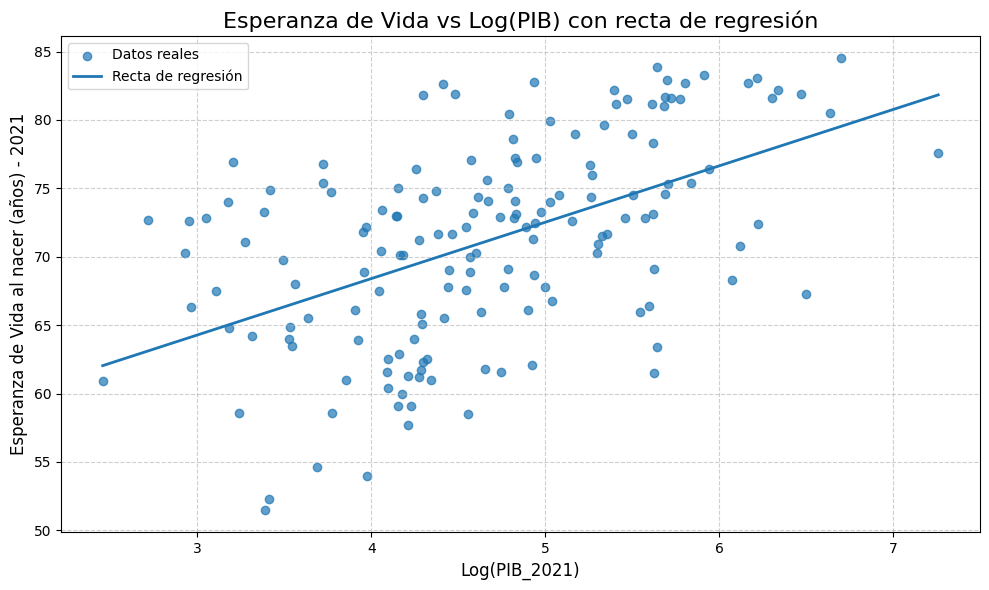

Gráfico 'residuos_regresion.png' guardado.


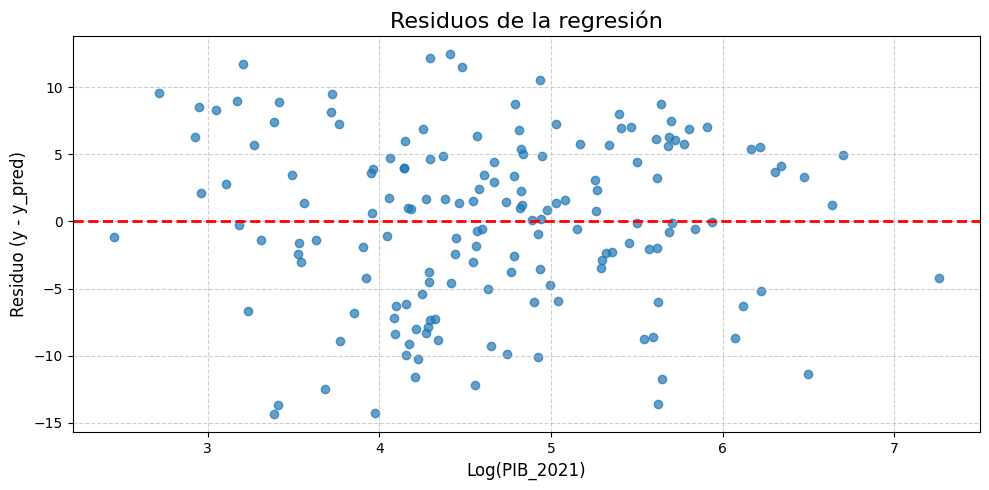


--- Distribución de los datos ---
Gráfico 'distribucion_datos.png' guardado.


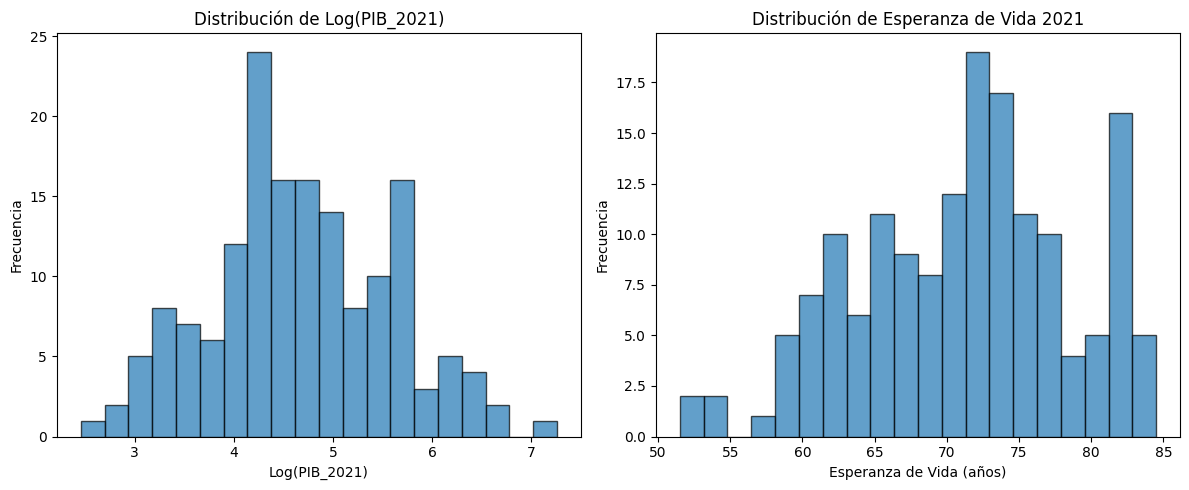

In [10]:
# --- IMPORTANTE: arriba en tu código agrega ---
import seaborn as sns

# ============================================================
# EXTRA: Heatmap, correlación, regresión, R2, MSE, RMSE y distribuciones
# ============================================================

# 1) HEATMAP DE CORRELACIONES
print("\n--- Heatmap de correlaciones ---")
vars_corr = ['GDP_2021', 'Log_GDP_2021', 'LifeExpectancy_2021']
corr_matrix = merged_df_clean[vars_corr].corr()
print(corr_matrix)

plt.figure(figsize=(6, 4))
sns.heatmap(corr_matrix, annot=True, fmt=".2f", cmap="coolwarm")
plt.title("Matriz de correlación")
plt.tight_layout()
plt.savefig("heatmap_correlaciones.png")
print("Heatmap 'heatmap_correlaciones.png' guardado.")
plt.show()

# 2) CORRELACIÓN SIMPLE (Pearson) ENTRE Log(PIB) Y ESPERANZA DE VIDA
print("\n--- Correlación Pearson entre Log_GDP_2021 y LifeExpectancy_2021 ---")
corr_pearson = merged_df_clean[['Log_GDP_2021', 'LifeExpectancy_2021']].corr().iloc[0, 1]
print(f"Correlación de Pearson: {corr_pearson:.4f}")

# 3) REGRESIÓN LINEAL (LifeExpectancy_2021 ~ Log_GDP_2021)
print("\n--- Regresión lineal simple ---")

# Variables
x = merged_df_clean['Log_GDP_2021'].values
y = merged_df_clean['LifeExpectancy_2021'].values

# Ajuste de regresión lineal con numpy (y = m*x + b)
m, b = np.polyfit(x, y, 1)
y_pred = m * x + b

print(f"Recta ajustada: y = {m:.4f} * x + {b:.4f}")

# 4) MÉTRICAS: R2, MSE, RMSE
residuals = y - y_pred

mse = np.mean(residuals ** 2)
rmse = np.sqrt(mse)

ss_res = np.sum(residuals ** 2)
ss_tot = np.sum((y - np.mean(y)) ** 2)
r2 = 1 - ss_res / ss_tot

print(f"MSE  (Error cuadrático medio): {mse:.4f}")
print(f"RMSE (Raíz del MSE): {rmse:.4f}")
print(f"R²   (Coeficiente de determinación): {r2:.4f}")

# 5) GRÁFICOS DE LA REGRESIÓN

# 5a) Dispersión + recta de regresión
plt.figure(figsize=(10, 6))
plt.scatter(x, y, alpha=0.7, label='Datos reales')
# Para dibujar la recta ordenada en x
x_line = np.linspace(x.min(), x.max(), 100)
y_line = m * x_line + b
plt.plot(x_line, y_line, linewidth=2, label='Recta de regresión')

plt.title('Esperanza de Vida vs Log(PIB) con recta de regresión', fontsize=16)
plt.xlabel('Log(PIB_2021)', fontsize=12)
plt.ylabel('Esperanza de Vida al nacer (años) - 2021', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.6)
plt.legend()
plt.tight_layout()
plt.savefig("regresion_lineal_gdp_lifeexp.png")
print("Gráfico 'regresion_lineal_gdp_lifeexp.png' guardado.")
plt.show()

# 5b) Gráfico de residuos
plt.figure(figsize=(10, 5))
plt.scatter(x, residuals, alpha=0.7)
plt.axhline(0, color='red', linestyle='--', linewidth=2)
plt.title('Residuos de la regresión', fontsize=16)
plt.xlabel('Log(PIB_2021)', fontsize=12)
plt.ylabel('Residuo (y - y_pred)', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()
plt.savefig("residuos_regresion.png")
print("Gráfico 'residuos_regresion.png' guardado.")
plt.show()

# 6) DISTRIBUCIÓN DE LOS DATOS

print("\n--- Distribución de los datos ---")

plt.figure(figsize=(12, 5))

# Histograma PIB (Log)
plt.subplot(1, 2, 1)
plt.hist(merged_df_clean['Log_GDP_2021'], bins=20, edgecolor='k', alpha=0.7)
plt.title('Distribución de Log(PIB_2021)')
plt.xlabel('Log(PIB_2021)')
plt.ylabel('Frecuencia')

# Histograma Esperanza de Vida
plt.subplot(1, 2, 2)
plt.hist(merged_df_clean['LifeExpectancy_2021'], bins=20, edgecolor='k', alpha=0.7)
plt.title('Distribución de Esperanza de Vida 2021')
plt.xlabel('Esperanza de Vida (años)')
plt.ylabel('Frecuencia')

plt.tight_layout()
plt.savefig("distribucion_datos.png")
print("Gráfico 'distribucion_datos.png' guardado.")
plt.show()
